В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



https://github.com/valeriya-reva/ml_course_hw/blob/main/Less_2/hw_2_3_1_helpers/process_bank_churn.py

In [1]:
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

from hw_2_3_1_helpers.process_bank_churn import preprocess_data, preprocess_new_data

In [2]:
train_df = pd.read_csv("../../data/data_kaggle_01/train.csv")
test_df = pd.read_csv("../../data/data_kaggle_01/test.csv")
sample_submission = pd.read_csv("../../data/data_kaggle_01/sample_submission.csv")

In [3]:
X_train, y_train, X_val, y_val, input_cols, scaler, encoder = preprocess_data(train_df, scaler_numeric=True)

X_test = preprocess_new_data(test_df, input_cols=input_cols, scaler=scaler)

**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [4]:
# Встановлюємо random_state для відтворюваності
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [5]:
# Прогнозуємо ймовірності класу 1
y_train_pred_proba = tree.predict_proba(X_train)[:, 1]
y_val_pred_proba = tree.predict_proba(X_val)[:, 1]

roc_auc_train = roc_auc_score(y_train, y_train_pred_proba)
roc_auc_val = roc_auc_score(y_val, y_val_pred_proba)

print(f"Train ROC AUC: {roc_auc_train:.3f}")
print(f"Validation ROC AUC: {roc_auc_val:.3f}")

Train ROC AUC: 1.000
Validation ROC AUC: 0.770


In [6]:
print("Tree depth:", tree.get_depth())

Tree depth: 26


In [7]:
# Навчаємо дерево з глибиною 2
tree2 = DecisionTreeClassifier(max_depth=2, random_state=42)
tree2.fit(X_train, y_train)

# Важливість ознак
importances = tree2.feature_importances_
features = X_train.columns

# Вивести у вигляді таблиці (або DataFrame)
for feat, imp in zip(features, importances):
    print(f"{feat}: {imp:.4f}")

CreditScore: 0.0000
Gender: 0.0000
Age: 0.7150
Tenure: 0.0000
Balance: 0.0000
NumOfProducts: 0.2850
HasCrCard: 0.0000
IsActiveMember: 0.0000
EstimatedSalary: 0.0000
Geography_Germany: 0.0000
Geography_Spain: 0.0000


             feature  importance
2                Age    0.714962
5      NumOfProducts    0.285038
0        CreditScore    0.000000
1             Gender    0.000000
3             Tenure    0.000000
4            Balance    0.000000
6          HasCrCard    0.000000
7     IsActiveMember    0.000000
8    EstimatedSalary    0.000000
9  Geography_Germany    0.000000


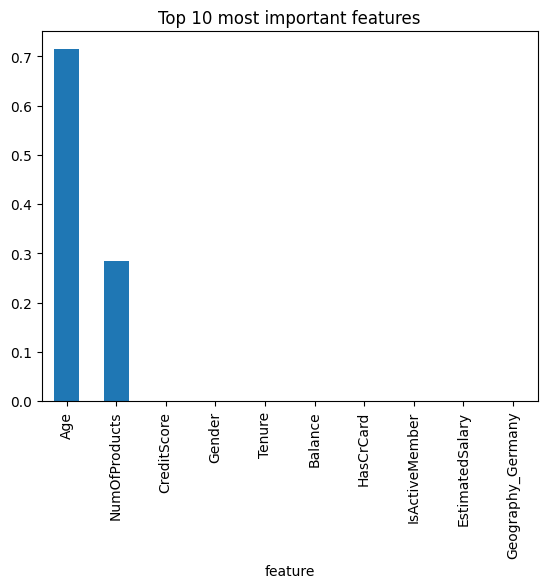

In [8]:
importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Топ-10
print(importance_df.head(10))

# Або barplot:
import matplotlib.pyplot as plt

importance_df.head(10).plot(kind='bar', x='feature', y='importance', legend=False)
plt.title('Top 10 most important features')
plt.show()

In [9]:
# Прогноз ймовірностей для дерева глибиною 2
y_train_pred_proba2 = tree2.predict_proba(X_train)[:, 1]
y_val_pred_proba2 = tree2.predict_proba(X_val)[:, 1]

roc_auc_train2 = roc_auc_score(y_train, y_train_pred_proba2)
roc_auc_val2 = roc_auc_score(y_val, y_val_pred_proba2)

print(f"Train ROC AUC (depth=2): {roc_auc_train2:.3f}")
print(f"Validation ROC AUC (depth=2): {roc_auc_val2:.3f}")

print("Tree2 depth:", tree2.get_depth())


Train ROC AUC (depth=2): 0.843
Validation ROC AUC (depth=2): 0.846
Tree2 depth: 2


**Висновки**

Дерево без обмеження глибини (depth=26):

- Train ROC AUC = 1.000 — явне перенавчання, модель ідеально запам’ятала навчальні дані.

- Validation ROC AUC = 0.770 — значно гірше, що підтверджує overfitting.

- Глибина дерева — 26 — дуже складна модель, що не узагальнює.

Дерево глибиною 2:

- Train ROC AUC = 0.843, Validation ROC AUC = 0.846 — значення метрик майже співпадають, модель добре узагальнює і не має перенавчання.

- Глибина дерева — 2 — модель дуже проста, рішення приймаються на основі кількох ознак.

- Найважливіші ознаки: Age, NumOfProducts — саме вони формують розділення у простому дереві, всі інші майже не впливають.

**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [10]:
tree3 = DecisionTreeClassifier(max_depth=4, random_state=42)
tree3.fit(X_train, y_train)

y_train_pred_proba3 = tree3.predict_proba(X_train)[:, 1]
y_val_pred_proba3 = tree3.predict_proba(X_val)[:, 1]

roc_auc_train3 = roc_auc_score(y_train, y_train_pred_proba3)
roc_auc_val3 = roc_auc_score(y_val, y_val_pred_proba3)

print(f"max_depth=4, ROC AUC train: {roc_auc_train3:.3f}, val: {roc_auc_val3:.3f}")


max_depth=4, ROC AUC train: 0.911, val: 0.911


In [11]:
tree4 = DecisionTreeClassifier(max_leaf_nodes=15, random_state=42)
tree4.fit(X_train, y_train)

y_train_pred_proba4 = tree4.predict_proba(X_train)[:, 1]
y_val_pred_proba4 = tree4.predict_proba(X_val)[:, 1]

roc_auc_train4 = roc_auc_score(y_train, y_train_pred_proba4)
roc_auc_val4 = roc_auc_score(y_val, y_val_pred_proba4)

print(f"max_leaf_nodes=15, ROC AUC train: {roc_auc_train4:.3f}, val: {roc_auc_val4:.3f}")


max_leaf_nodes=15, ROC AUC train: 0.914, val: 0.913


In [12]:
tree5 = DecisionTreeClassifier(max_depth=5, max_leaf_nodes=12, random_state=42)
tree5.fit(X_train, y_train)

y_train_pred_proba5 = tree5.predict_proba(X_train)[:, 1]
y_val_pred_proba5 = tree5.predict_proba(X_val)[:, 1]

roc_auc_train5 = roc_auc_score(y_train, y_train_pred_proba5)
roc_auc_val5 = roc_auc_score(y_val, y_val_pred_proba5)

print(f"max_depth=5, max_leaf_nodes=12, ROC AUC train: {roc_auc_train5:.3f}, val: {roc_auc_val5:.3f}")


max_depth=5, max_leaf_nodes=12, ROC AUC train: 0.907, val: 0.907


**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

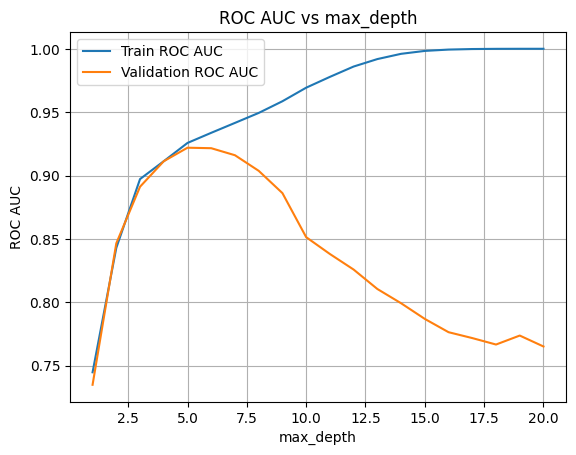

In [13]:
train_aucs = []
val_aucs = []
depths = range(1, 21)

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    y_train_proba = tree.predict_proba(X_train)[:, 1]
    y_val_proba = tree.predict_proba(X_val)[:, 1]
    train_aucs.append(roc_auc_score(y_train, y_train_proba))
    val_aucs.append(roc_auc_score(y_val, y_val_proba))

plt.plot(depths, train_aucs, label='Train ROC AUC')
plt.plot(depths, val_aucs, label='Validation ROC AUC')
plt.xlabel('max_depth')
plt.ylabel('ROC AUC')
plt.title('ROC AUC vs max_depth')
plt.legend()
plt.grid(True)
plt.show()


**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [14]:
best_depth = 5 
tree_best = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
tree_best.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [15]:
X_test = preprocess_new_data(
    test_df,
    input_cols=input_cols,
    scaler=scaler,
    reference_columns=X_train.columns
)

In [16]:
test_pred_proba = tree_best.predict_proba(X_test)[:, 1]

In [17]:
sample_submission['Exited'] = test_pred_proba

print(sample_submission.head())

      id    Exited
0  15000  0.041734
1  15001  0.027613
2  15002  0.027613
3  15003  0.770925
4  15004  0.027613


In [19]:
sample_submission.to_csv('data_hw_2_3/submission_tree_best.csv', index=False)

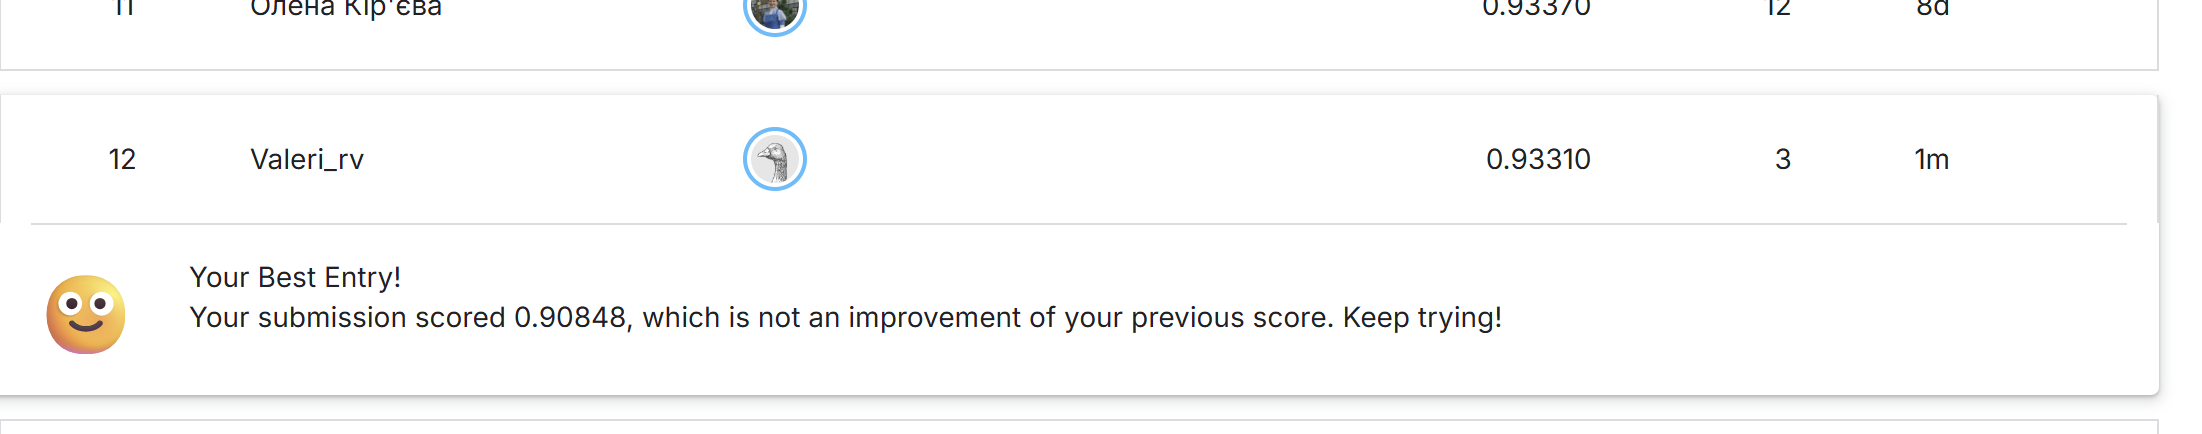